<a href="https://colab.research.google.com/github/lulubang541/ODL-Assignment/blob/main/ODL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ODL Assignment


In [ ]:
# Install the libraries required for the deep learning project.
# sys.executable ensures the packages are installed into the same
# Python environment currently used by this Jupyter Notebook.

import sys
import subprocess


def install_package(package_name):
    """Install a Python package into the current Jupyter environment."""
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            package_name
        ]
    )


required_packages = [
    "opencv-python",
    "tensorflow",
    "keras-tuner",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "pillow"
]

for package in required_packages:
    print(f"\nInstalling or updating: {package}")
    install_package(package)

print("\nAll required packages were installed successfully.")


Installing or updating: opencv-python

Installing or updating: tensorflow

Installing or updating: keras-tuner

Installing or updating: scikit-learn

Installing or updating: pandas

Installing or updating: numpy

Installing or updating: matplotlib

Installing or updating: pillow

All required packages were installed successfully.


Verify OpenCV

In [ ]:
import cv2

print("OpenCV imported successfully.")
print("OpenCV version:", cv2.__version__)

OpenCV imported successfully.
OpenCV version: 5.0.0


Full Libraries Imports

In [ ]:
import os
import gc
import cv2
import json
import time
import random
import hashlib
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import keras_tuner as kt

warnings.filterwarnings("ignore")

# Allow PIL to load truncated images for inspection.
# Corrupted files will still be detected separately.
ImageFile.LOAD_TRUNCATED_IMAGES = True

ImportError: cannot import name '_center' from 'numpy._core.umath' (/usr/local/lib/python3.12/dist-packages/numpy/_core/umath.py)

In [ ]:
%pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.5 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STANDARD PYTHON LIBRARIES
# ============================================================

import os
import gc
import sys
import json
import time
import random
import hashlib
import warnings

from pathlib import Path
from collections import Counter, defaultdict


# ============================================================
# DATA PROCESSING AND IMAGE LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from PIL import Image, ImageFile


# ============================================================
# MACHINE LEARNING EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss
)


# ============================================================
# DEEP LEARNING
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# ============================================================
# HYPERPARAMETER OPTIMISATION
# ============================================================

import keras_tuner as kt


# ============================================================
# GENERAL CONFIGURATION
# ============================================================

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# ENVIRONMENT VERIFICATION
# ============================================================

print("=" * 70)
print("ENVIRONMENT CHECK")
print("=" * 70)

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Scikit-learn imported successfully")
print("TensorFlow version:", tf.__version__)
print("Keras Tuner version:", kt.__version__)
print("Random seed:", SEED)

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print("GPU available:", gpu_devices)
else:
    print("GPU available: No")
    print("Training will use the CPU and may take longer.")

print("=" * 70)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 70)

ENVIRONMENT CHECK
Python version: 3.12.13
NumPy version: 2.0.2
Pandas version: 2.2.2
OpenCV version: 4.13.0
Scikit-learn imported successfully
TensorFlow version: 2.20.0
Keras Tuner version: 1.4.8
Random seed: 42
GPU available: No
Training will use the CPU and may take longer.
ALL LIBRARIES IMPORTED SUCCESSFULLY


Mount Google Drive

In [ ]:
import sys
import os

print("Python executable:", sys.executable)
print("Current directory:", os.getcwd())

try:
    import google.colab
    print("Environment: Google Colab")
except ImportError:
    print("Environment: Not Google Colab")

Python executable: /usr/bin/python3
Current directory: /content
Environment: Google Colab


In [ ]:
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os

MY_DRIVE = Path("/content/drive/MyDrive")

print("MyDrive exists:", MY_DRIVE.exists())

if MY_DRIVE.exists():
    print("MyDrive contents:")
    print(os.listdir(MY_DRIVE)[:20])
else:
    print("Google Drive is still not mounted.")

MyDrive exists: True
MyDrive contents:
['Seatru picsss', 'SEA Employee Data Form_8Apr2025.docx', 'Colab Notebooks']


Verify Classification folder


In [ ]:
from pathlib import Path
import os

BASE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/classification"
)

print("Classification folder exists:", BASE_PATH.exists())
print("Classification path:", BASE_PATH)

if BASE_PATH.exists():
    print("Folder contents:")
    print(os.listdir(BASE_PATH))
else:
    print("The classification folder could not be accessed.")

Classification folder exists: True
Classification path: /content/drive/MyDrive/Colab Notebooks/classification
Folder contents:
['seg_test', 'seg_pred', 'seg_train']


Automatically detect the inner folder structure

In [ ]:
from pathlib import Path

EXPECTED_CLASSES = {
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
}

VALID_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def resolve_labelled_folder(parent_folder, repeated_name):
    parent_folder = Path(parent_folder)

    possible_paths = [
        parent_folder,
        parent_folder / repeated_name
    ]

    for possible_path in possible_paths:
        if not possible_path.exists():
            continue

        child_folders = {
            item.name
            for item in possible_path.iterdir()
            if item.is_dir()
        }

        if EXPECTED_CLASSES.issubset(child_folders):
            return possible_path

    raise FileNotFoundError(
        f"Could not locate the six class folders inside:\n{parent_folder}"
    )


def resolve_prediction_folder(parent_folder, repeated_name):
    parent_folder = Path(parent_folder)

    possible_paths = [
        parent_folder,
        parent_folder / repeated_name
    ]

    for possible_path in possible_paths:
        if not possible_path.exists():
            continue

        image_files = [
            file_path
            for file_path in possible_path.rglob("*")
            if (
                file_path.is_file()
                and file_path.suffix.lower() in VALID_EXTENSIONS
            )
        ]

        if image_files:
            return possible_path

    raise FileNotFoundError(
        f"No prediction images were found inside:\n{parent_folder}"
    )


TRAIN_DIR = resolve_labelled_folder(
    BASE_PATH / "seg_train",
    "seg_train"
)

TEST_DIR = resolve_labelled_folder(
    BASE_PATH / "seg_test",
    "seg_test"
)

PRED_DIR = resolve_prediction_folder(
    BASE_PATH / "seg_pred",
    "seg_pred"
)

print("=" * 70)
print("DETECTED DATASET PATHS")
print("=" * 70)

print("Training directory:", TRAIN_DIR)
print("Testing directory:", TEST_DIR)
print("Prediction directory:", PRED_DIR)

DETECTED DATASET PATHS
Training directory: /content/drive/MyDrive/Colab Notebooks/classification/seg_train/seg_train
Testing directory: /content/drive/MyDrive/Colab Notebooks/classification/seg_test/seg_test
Prediction directory: /content/drive/MyDrive/Colab Notebooks/classification/seg_pred


Count the images

In [ ]:
def count_images(folder_path):
    return len(
        [
            file_path
            for file_path in Path(folder_path).rglob("*")
            if (
                file_path.is_file()
                and file_path.suffix.lower() in VALID_EXTENSIONS
            )
        ]
    )


training_count = count_images(TRAIN_DIR)
testing_count = count_images(TEST_DIR)
prediction_count = count_images(PRED_DIR)

print("=" * 70)
print("DATASET IMAGE COUNTS")
print("=" * 70)

print("Training images:", training_count)
print("Testing images:", testing_count)
print("Prediction images:", prediction_count)

print(
    "Total images:",
    training_count + testing_count + prediction_count
)

DATASET IMAGE COUNTS
Training images: 14034
Testing images: 3000
Prediction images: 7301
Total images: 24335


Create the output folders in Drive

In [ ]:
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/ODL_outputs"
)

MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
LOG_DIR = OUTPUT_DIR / "logs"

for folder in [
    OUTPUT_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    LOG_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Output directory:", OUTPUT_DIR)
print("Model directory:", MODEL_DIR)
print("Figure directory:", FIGURE_DIR)
print("Table directory:", TABLE_DIR)
print("Log directory:", LOG_DIR)

Output directory: /content/drive/MyDrive/Colab Notebooks/ODL_outputs
Model directory: /content/drive/MyDrive/Colab Notebooks/ODL_outputs/models
Figure directory: /content/drive/MyDrive/Colab Notebooks/ODL_outputs/figures
Table directory: /content/drive/MyDrive/Colab Notebooks/ODL_outputs/tables
Log directory: /content/drive/MyDrive/Colab Notebooks/ODL_outputs/logs


Phase 1: Dataset Inventory and EDA

In [ ]:
# ============================================================
# IDENTIFY DATASET CLASSES
# ============================================================

class_names = sorted(
    folder.name
    for folder in TRAIN_DIR.iterdir()
    if folder.is_dir()
)

num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

assert num_classes == 6, (
    f"Expected 6 classes, but found {num_classes}."
)

assert class_names == sorted(EXPECTED_CLASSES), (
    "The detected class names do not match the expected classes."
)

Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


Create Image Inventory

In [ ]:
# ============================================================
# CREATE DATASET INVENTORY
# ============================================================

def create_image_inventory(root_directory, split_name):
    """
    Create one metadata record for every labelled image.
    """

    records = []

    for class_folder in sorted(root_directory.iterdir()):
        if not class_folder.is_dir():
            continue

        class_name = class_folder.name

        for file_path in class_folder.rglob("*"):
            if (
                file_path.is_file()
                and file_path.suffix.lower() in VALID_EXTENSIONS
            ):
                records.append(
                    {
                        "split": split_name,
                        "class_name": class_name,
                        "filename": file_path.name,
                        "filepath": str(file_path),
                        "extension": file_path.suffix.lower(),
                        "file_size_kb":
                            file_path.stat().st_size / 1024
                    }
                )

    return pd.DataFrame(records)


train_inventory = create_image_inventory(
    TRAIN_DIR,
    "train"
)

test_inventory = create_image_inventory(
    TEST_DIR,
    "test"
)

full_inventory = pd.concat(
    [
        train_inventory,
        test_inventory
    ],
    ignore_index=True
)

print("=" * 70)
print("DATASET INVENTORY")
print("=" * 70)

print("Training images:", len(train_inventory))
print("Testing images:", len(test_inventory))
print("Total labelled images:", len(full_inventory))

display(full_inventory.head())

DATASET INVENTORY
Training images: 14034
Testing images: 3000
Total labelled images: 17034


,split,class_name,filename,filepath,extension,file_size_kb
0,train,buildings,19347.jpg,/content/drive/MyDrive/Colab Notebooks/classif...,.jpg,13.588867
1,train,buildings,19332.jpg,/content/drive/MyDrive/Colab Notebooks/classif...,.jpg,9.919922
2,train,buildings,1943.jpg,/content/drive/MyDrive/Colab Notebooks/classif...,.jpg,17.446289
3,train,buildings,19383.jpg,/content/drive/MyDrive/Colab Notebooks/classif...,.jpg,19.159180
4,train,buildings,19344.jpg,/content/drive/MyDrive/Colab Notebooks/classif...,.jpg,13.840820


Save Inventory

In [ ]:
inventory_path = TABLE_DIR / "image_inventory.csv"

full_inventory.to_csv(
    inventory_path,
    index=False
)

print("Inventory saved to:")
print(inventory_path)

Inventory saved to:
/content/drive/MyDrive/Colab Notebooks/ODL_outputs/tables/image_inventory.csv


Class Distribution table

In [ ]:
# ============================================================
# CLASS DISTRIBUTION ANALYSIS
# ============================================================

class_distribution = (
    full_inventory
    .groupby(
        [
            "split",
            "class_name"
        ]
    )
    .size()
    .reset_index(
        name="image_count"
    )
)

class_distribution["percentage_within_split"] = (
    class_distribution
    .groupby("split")["image_count"]
    .transform(
        lambda values:
        values / values.sum() * 100
    )
)

display(class_distribution)

class_distribution.to_csv(
    TABLE_DIR / "class_distribution.csv",
    index=False
)

,split,class_name,image_count,percentage_within_split
0,test,buildings,437,14.566667
1,test,forest,474,15.800000
2,test,glacier,553,18.433333
3,test,mountain,525,17.500000
4,test,sea,510,17.000000
5,test,street,501,16.700000
6,train,buildings,2191,15.612085
7,train,forest,2271,16.182129
8,train,glacier,2404,17.129828
9,train,mountain,2512,17.899387


Training Class distribution graph

In [ ]:
import matplotlib.pyplot as plt

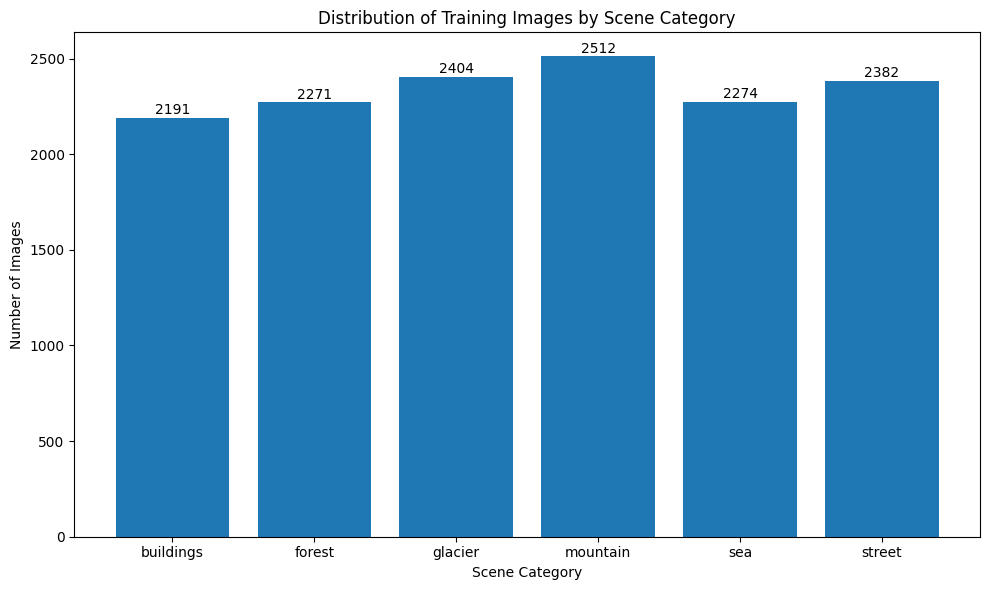

In [ ]:
training_class_counts = (
    train_inventory["class_name"]
    .value_counts()
    .reindex(class_names)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    training_class_counts.index,
    training_class_counts.values
)

plt.title(
    "Distribution of Training Images by Scene Category"
)
plt.xlabel("Scene Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

for bar, value in zip(
    bars,
    training_class_counts.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "training_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Combined Class distribution table

In [ ]:
# ============================================================
# COMBINED TRAINING AND TESTING DISTRIBUTION
# ============================================================

training_class_counts = (
    train_inventory["class_name"]
    .value_counts()
    .reindex(class_names)
    .fillna(0)
    .astype(int)
)

testing_class_counts = (
    test_inventory["class_name"]
    .value_counts()
    .reindex(class_names)
    .fillna(0)
    .astype(int)
)

distribution_summary = pd.DataFrame(
    {
        "class_name": class_names,
        "training_images": training_class_counts.values,
        "testing_images": testing_class_counts.values
    }
)

distribution_summary["total_images"] = (
    distribution_summary["training_images"]
    + distribution_summary["testing_images"]
)

distribution_summary["training_percentage"] = (
    distribution_summary["training_images"]
    / distribution_summary["training_images"].sum()
    * 100
)

distribution_summary["testing_percentage"] = (
    distribution_summary["testing_images"]
    / distribution_summary["testing_images"].sum()
    * 100
)

display(distribution_summary)

distribution_summary.to_csv(
    TABLE_DIR / "combined_class_distribution.csv",
    index=False
)

,class_name,training_images,testing_images,total_images,training_percentage,testing_percentage
0,buildings,2191,437,2628,15.612085,14.566667
1,forest,2271,474,2745,16.182129,15.800000
2,glacier,2404,553,2957,17.129828,18.433333
3,mountain,2512,525,3037,17.899387,17.500000
4,sea,2274,510,2784,16.203506,17.000000
5,street,2382,501,2883,16.973065,16.700000


Inspect Image properties

In [ ]:
# ============================================================
# IMAGE QUALITY INSPECTION WITH PROGRESS BAR
# ============================================================

import numpy as np
import pandas as pd
import cv2

from PIL import Image
from tqdm.auto import tqdm


def inspect_image_properties(dataframe):
    """
    Inspect every labelled image and return a DataFrame
    containing image dimensions and quality measurements.
    """

    results = []

    # tqdm shows the progress, percentage, speed, and estimated time.
    progress_bar = tqdm(
        dataframe.itertuples(index=False),
        total=len(dataframe),
        desc="Inspecting images",
        unit="image"
    )

    for row in progress_bar:
        record = {
            "filepath": row.filepath,
            "filename": row.filename,
            "class_name": row.class_name,
            "split": row.split,
            "width": np.nan,
            "height": np.nan,
            "channels": np.nan,
            "aspect_ratio": np.nan,
            "mean_brightness": np.nan,
            "blur_score": np.nan,
            "is_corrupted": False,
            "error_message": ""
        }

        try:
            # Verify that PIL can decode the file.
            with Image.open(row.filepath) as image:
                image.verify()

            # Read the image numerically using OpenCV.
            image_array = cv2.imread(row.filepath)

            if image_array is None:
                raise ValueError(
                    "OpenCV could not decode the image."
                )

            height, width = image_array.shape[:2]

            if image_array.ndim == 2:
                channels = 1
                grayscale_image = image_array
            else:
                channels = image_array.shape[2]

                grayscale_image = cv2.cvtColor(
                    image_array,
                    cv2.COLOR_BGR2GRAY
                )

            record["width"] = int(width)
            record["height"] = int(height)
            record["channels"] = int(channels)
            record["aspect_ratio"] = float(
                width / height
            )

            record["mean_brightness"] = float(
                np.mean(grayscale_image)
            )

            # Lower values generally indicate blurrier images.
            record["blur_score"] = float(
                cv2.Laplacian(
                    grayscale_image,
                    cv2.CV_64F
                ).var()
            )

        except Exception as error:
            record["is_corrupted"] = True
            record["error_message"] = str(error)

        results.append(record)

        # Show the current number of corrupted images.
        corrupted_count = sum(
            item["is_corrupted"] for item in results
        )

        progress_bar.set_postfix(
            corrupted=corrupted_count
        )

    return pd.DataFrame(results)


image_quality_df = inspect_image_properties(
    full_inventory
)

print("\nImage-quality inspection completed.")

display(image_quality_df.head())

Inspecting images:   0%|          | 0/17034 [00:00<?, ?image/s]

KeyboardInterrupt: 

In [ ]:
# ============================================================
# IMAGE QUALITY INSPECTION
# ============================================================

def inspect_image_properties(dataframe):
    """
    Inspect every labelled image and return a DataFrame
    containing image dimensions and quality measurements.
    """

    results = []
    total_images = len(dataframe)

    for index, row in enumerate(
        dataframe.itertuples(),
        start=1
    ):
        record = {
            "filepath": row.filepath,
            "filename": row.filename,
            "class_name": row.class_name,
            "split": row.split,
            "width": np.nan,
            "height": np.nan,
            "channels": np.nan,
            "aspect_ratio": np.nan,
            "mean_brightness": np.nan,
            "blur_score": np.nan,
            "is_corrupted": False,
            "error_message": ""
        }

        try:
            # Verify that PIL can decode the file.
            with Image.open(row.filepath) as image:
                image.verify()

            # Read the image numerically using OpenCV.
            image_array = cv2.imread(row.filepath)

            if image_array is None:
                raise ValueError(
                    "OpenCV could not decode the image."
                )

            height, width = image_array.shape[:2]

            if image_array.ndim == 2:
                channels = 1
                grayscale_image = image_array
            else:
                channels = image_array.shape[2]

                grayscale_image = cv2.cvtColor(
                    image_array,
                    cv2.COLOR_BGR2GRAY
                )

            record["width"] = int(width)
            record["height"] = int(height)
            record["channels"] = int(channels)
            record["aspect_ratio"] = float(
                width / height
            )

            record["mean_brightness"] = float(
                np.mean(grayscale_image)
            )

            # Variance of the Laplacian is used as a blur indicator.
            # A lower value generally represents a blurrier image.
            record["blur_score"] = float(
                cv2.Laplacian(
                    grayscale_image,
                    cv2.CV_64F
                ).var()
            )

        except Exception as error:
            record["is_corrupted"] = True
            record["error_message"] = str(error)

        results.append(record)

        if index % 2000 == 0 or index == total_images:
            print(
                f"Processed {index:,} of "
                f"{total_images:,} images"
            )

    return pd.DataFrame(results)


image_quality_df = inspect_image_properties(
    full_inventory
)

print("\nImage-quality inspection completed.")

display(image_quality_df.head())

Processed 2,000 of 17,034 images
Processed 4,000 of 17,034 images
Processed 6,000 of 17,034 images
Processed 8,000 of 17,034 images
Processed 10,000 of 17,034 images
Processed 12,000 of 17,034 images
Processed 14,000 of 17,034 images


Save the image quality results

In [ ]:
image_quality_path = (
    TABLE_DIR / "image_quality_analysis.csv"
)

image_quality_df.to_csv(
    image_quality_path,
    index=False
)

print("Image-quality analysis saved to:")
print(image_quality_path)